In [1]:
from __future__ import annotations
from typing import TYPE_CHECKING

import kagglehub
import polars as pl
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import torchaudio, librosa, torch

from modules.preprocessing.dataframe_process import filter_coughvid_df
from modules.plotting.plotters import *
from modules.preprocessing.audio_process import *
from IPython.display import Audio

if TYPE_CHECKING:
    from torch import Tensor

In [2]:
def make_path(audio_name: str) -> str:
    return f"data/public_dataset_v3_wav/{audio_name.split(".")[0]}.wav"

def librosa_wave_to_torch(arr) -> Tensor:
    print(arr.shape)
    return torch.from_numpy(arr).unsqueeze(0)

# load cough db if not downloaded

In [ ]:
path: str = kagglehub.dataset_download("orvile/coughvid-v3", output_dir="data")
print("Path to dataset files:", path)

100%|██████████| 2.15G/2.15G [02:02<00:00, 18.8MB/s]

Extracting files...


Path to dataset files: data


In [3]:
df: pl.DataFrame = pl.read_csv('data/tabular_form/tabular_form/coughvid_v3.csv', schema_overrides={"age":pl.Float32})
df

datetime,cough_detected,latitude,longitude,age,gender,respiratory_condition,fever_muscle_pain,status,file_name,audio_name
str,f64,f64,f64,f32,str,bool,bool,str,str,str
"""2020-04-13T16:30:16.716367+00:…",0.9761,41.8,61.1,17.0,"""female""",true,false,"""healthy""","""0f0762c8-4b9a-4c1e-a6c3-230f9d…","""0f0762c8-4b9a-4c1e-a6c3-230f9d…"
"""2020-11-02T07:42:22.878931+00:…",0.0217,null,null,62.0,"""male""",true,false,"""healthy""","""1ed36fa5-19bb-434b-b41f-7fa2b9…","""1ed36fa5-19bb-434b-b41f-7fa2b9…"
"""2020-11-18T20:30:54.833009+00:…",0.9886,42.4,3.2,39.0,"""male""",false,false,"""healthy""","""48b283df-8bda-4766-b02e-0efee9…","""48b283df-8bda-4766-b02e-0efee9…"
"""2020-11-27T11:10:09.815282+00:…",0.8499,null,null,73.0,"""male""",false,false,"""healthy""","""afd8d2b2-b4f1-49e0-ace8-29af9e…","""afd8d2b2-b4f1-49e0-ace8-29af9e…"
"""2020-04-11T16:12:17.509769+00:…",0.7665,null,null,37.0,"""male""",false,false,"""healthy""","""9e88a91b-9cc6-4376-b7c4-6fa5b3…","""9e88a91b-9cc6-4376-b7c4-6fa5b3…"
…,…,…,…,…,…,…,…,…,…,…
"""2020-04-14T04:12:48.762596+00:…",0.0102,11.0,-74.8,null,null,null,null,null,"""55add438-3154-4e6c-aa9b-4a1f53…","""55add438-3154-4e6c-aa9b-4a1f53…"
"""2020-04-23T16:00:25.946130+00:…",0.6395,40.9,72.2,17.0,"""female""",true,true,"""healthy""","""cedae989-c49c-4c60-a8c7-1ca431…","""cedae989-c49c-4c60-a8c7-1ca431…"
"""2020-10-20T23:26:03.137144+00:…",0.6098,null,null,41.0,"""male""",false,false,"""healthy""","""653ede37-955a-40a0-a68d-b78746…","""653ede37-955a-40a0-a68d-b78746…"


In [4]:
filtered_df: pl.DataFrame = filter_coughvid_df(df)
filtered_df.head()


datetime,cough_detected,latitude,longitude,age,gender,respiratory_condition,fever_muscle_pain,status,file_name,audio_name
str,f64,f64,f64,f32,str,bool,bool,str,str,str
"""2020-04-13T16:30:16.716367+00:…",0.9761,41.8,61.1,17.0,"""female""",true,false,"""healthy""","""0f0762c8-4b9a-4c1e-a6c3-230f9d…","""0f0762c8-4b9a-4c1e-a6c3-230f9d…"
"""2020-11-18T20:30:54.833009+00:…",0.9886,42.4,3.2,39.0,"""male""",false,false,"""healthy""","""48b283df-8bda-4766-b02e-0efee9…","""48b283df-8bda-4766-b02e-0efee9…"
"""2020-11-27T11:10:09.815282+00:…",0.8499,null,null,73.0,"""male""",false,false,"""healthy""","""afd8d2b2-b4f1-49e0-ace8-29af9e…","""afd8d2b2-b4f1-49e0-ace8-29af9e…"
"""2021-05-08T18:57:27.198023+00:…",0.8575,null,null,42.0,"""female""",false,false,"""healthy""","""50d84a8d-3b91-425d-b6b6-618b44…","""50d84a8d-3b91-425d-b6b6-618b44…"
"""2020-11-13T20:36:22.940967+00:…",0.8582,null,null,57.0,"""male""",false,false,"""healthy""","""691a5311-c229-4788-8279-05bed7…","""691a5311-c229-4788-8279-05bed7…"


In [5]:
filtered_df["status"].describe()
filtered_df.filter(pl.col("status") == "healthy")

datetime,cough_detected,latitude,longitude,age,gender,respiratory_condition,fever_muscle_pain,status,file_name,audio_name
str,f64,f64,f64,f32,str,bool,bool,str,str,str
"""2020-04-13T16:30:16.716367+00:…",0.9761,41.8,61.1,17.0,"""female""",true,false,"""healthy""","""0f0762c8-4b9a-4c1e-a6c3-230f9d…","""0f0762c8-4b9a-4c1e-a6c3-230f9d…"
"""2020-11-18T20:30:54.833009+00:…",0.9886,42.4,3.2,39.0,"""male""",false,false,"""healthy""","""48b283df-8bda-4766-b02e-0efee9…","""48b283df-8bda-4766-b02e-0efee9…"
"""2020-11-27T11:10:09.815282+00:…",0.8499,null,null,73.0,"""male""",false,false,"""healthy""","""afd8d2b2-b4f1-49e0-ace8-29af9e…","""afd8d2b2-b4f1-49e0-ace8-29af9e…"
"""2021-05-08T18:57:27.198023+00:…",0.8575,null,null,42.0,"""female""",false,false,"""healthy""","""50d84a8d-3b91-425d-b6b6-618b44…","""50d84a8d-3b91-425d-b6b6-618b44…"
"""2020-11-13T20:36:22.940967+00:…",0.8582,null,null,57.0,"""male""",false,false,"""healthy""","""691a5311-c229-4788-8279-05bed7…","""691a5311-c229-4788-8279-05bed7…"
…,…,…,…,…,…,…,…,…,…,…
"""2020-08-11T18:35:10.836484+00:…",0.9854,31.7,74.9,23.0,"""female""",false,false,"""healthy""","""c2b9aef1-d37e-4840-8813-9a122b…","""c2b9aef1-d37e-4840-8813-9a122b…"
"""2020-11-25T22:02:22.740075+00:…",0.9911,43.7,7.1,39.0,"""female""",false,false,"""healthy""","""9eb38664-0947-455a-954e-3d5415…","""9eb38664-0947-455a-954e-3d5415…"
"""2020-04-17T15:22:27.018924+00:…",0.9779,40.4,-3.6,46.0,"""male""",false,false,"""healthy""","""8ed39beb-0f82-4d20-b46d-cff6d9…","""8ed39beb-0f82-4d20-b46d-cff6d9…"


(52920,)


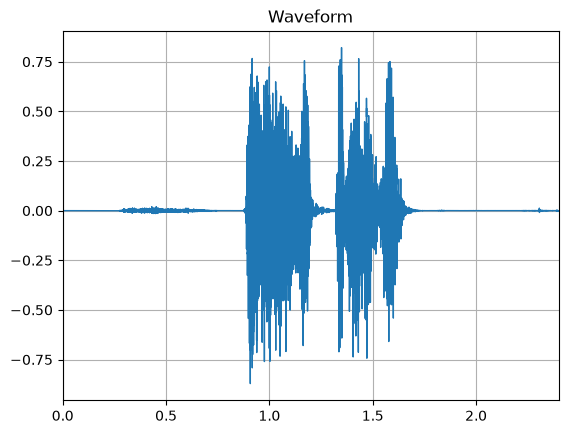

In [6]:
# Load Audio

COUGH_WAVE, SAMPLE_RATE = librosa.load(
    make_path(df["audio_name"][0])
)
plot_waveform(librosa_wave_to_torch(COUGH_WAVE), SAMPLE_RATE)

In [6]:
Audio(make_path(df["audio_name"][0]))

# Segmentation test

2
(11263,)
(8787,)


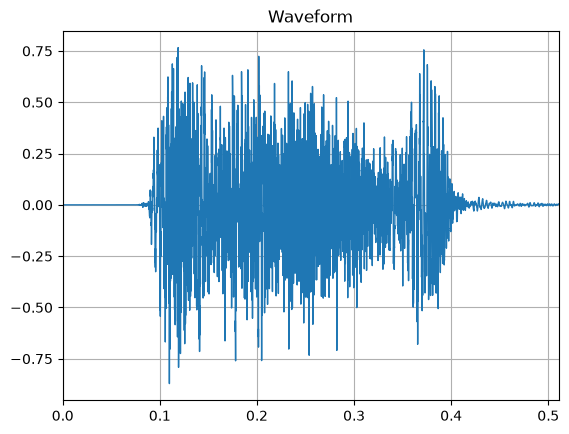

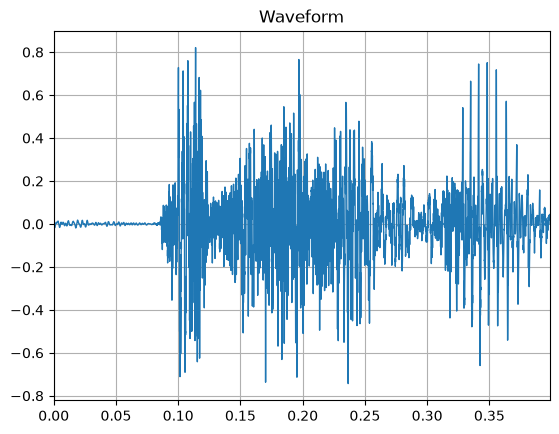

In [7]:
COUGH_WAVES, _ = segment_cough(COUGH_WAVE, SAMPLE_RATE, 0.1, 0.1)
print(len(COUGH_WAVES))
for COUGH in COUGH_WAVES:
    plot_waveform(librosa_wave_to_torch(COUGH), SAMPLE_RATE)

(11263,)
torch.Size([256, 22])
(11263,)


c:\Users\drewq\Documents\code\GitHub\senior_design\Senior_Design\project_notebooks\.venv\Lib\site-packages\torchaudio\functional\functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (256) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


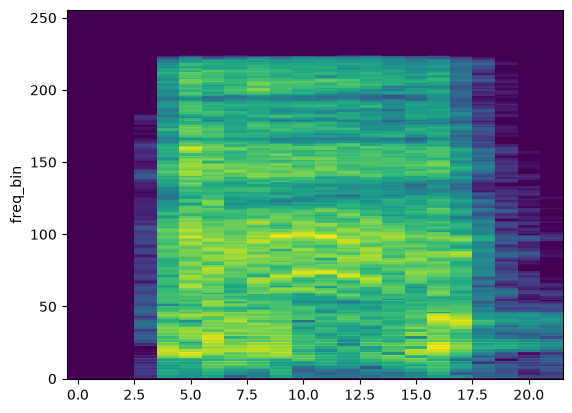

In [8]:
mel_pipeline: MelSpectrogramPipeline = MelSpectrogramPipeline(n_fft=1024)
result: Tensor = mel_pipeline.forward(librosa_wave_to_torch(COUGH_WAVES[0]), SAMPLE_RATE)
plot_spectrogram(result[0])
print(result[0].shape)
Audio(data=librosa_wave_to_torch(COUGH_WAVES[0]), rate=16000)

(11263,)
torch.Size([256, 22])
(11263,)


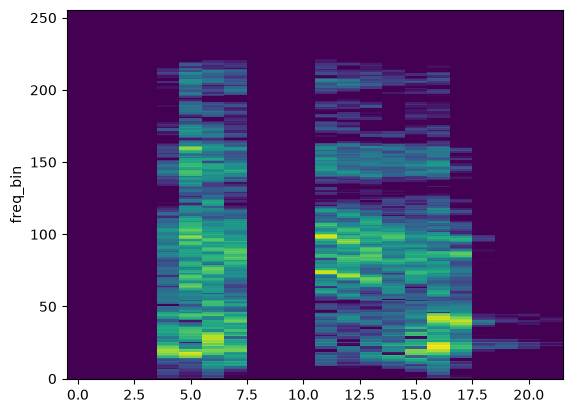

In [15]:
mel_pipeline: MelSpectrogramPipeline = MelSpectrogramPipeline(n_fft=1024, transforms=SpecAugmentations())
result: Tensor = mel_pipeline.forward(librosa_wave_to_torch(COUGH_WAVES[0]), SAMPLE_RATE)
plot_spectrogram(result[0])
print(result[0].shape)
Audio(data=mel_pipeline.make_transform_waveform(librosa_wave_to_torch(COUGH_WAVES[0]), n_iter=64), rate=16000)

In [ ]:
re

In [24]:
from modules.preprocessing.audio_process import MFCCPipeline
mfcc_pipeline: MFCCPipeline = MFCCPipeline(n_mfcc=256)
result: Tensor = mfcc_pipeline.forward(librosa_wave_to_torch(COUGH_WAVES[0]))
plot_spectrogram(result[0])

(11263,)


AttributeError: 'MFCCPipeline' object has no attribute 'aug_spec'

(11263,)
torch.Size([276, 22])
(11263,)


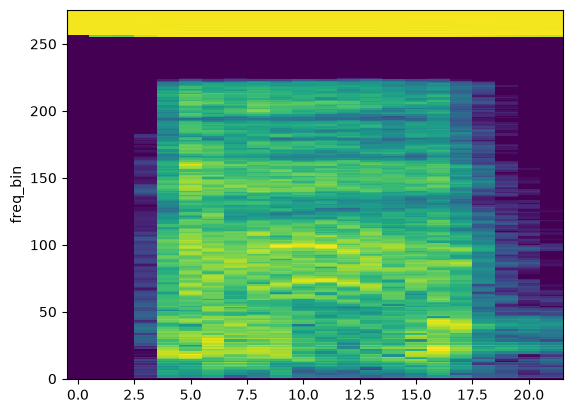

In [9]:
mel_pipeline: ComombinedSpectMFCCPipeline = ComombinedSpectMFCCPipeline(n_fft=1024, transforms=lambda x: x)
result: Tensor = mel_pipeline.forward(librosa_wave_to_torch(COUGH_WAVES[0]))
plot_spectrogram(result[0])
print(result[0].shape)
Audio(data=mel_pipeline.make_transform_waveform(librosa_wave_to_torch(COUGH_WAVES[0]), n_iter=64), rate=16000)